<a href="https://colab.research.google.com/github/Augusto-Seixas-UFV/ElementsOfDataScience/blob/v1/ELT_579_SEMANA_02_Fenotipagem_de_Tomateiro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Estrutura Geral**
O notebook implementa um pipeline de regressão linear com seleção de features usando RFE (Recursive Feature Elimination) para prever uma variável "Severidade" a partir de índices de vegetação.

**Objetivo Principal:** Prever a severidade de algum problema (doença, praga, estresse hídrico, etc.) em plantas de tomate com base em índices de vegetação calculados em diferentes dias.

**Baseline: Versão apresentada pelo professor.**

**1. Importações, Carregamento e Preparação**

In [1]:
# -*- coding: utf-8 -*-
"""

@author: sarvio valente

"""
# Bibliotecas essenciais para análise de dados e visualização
from google.colab import files
uploaded = files.upload()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


Saving dataset_problema2.csv to dataset_problema2.csv


In [2]:
# Carrega dataset com índices de vegetação
df = pd.read_csv('dataset_problema2.csv')
df.head()

X = df.drop(['id', 'Severidade'], axis = 1)
y = df['Severidade']


**2. Divisão Train/Test:**

In [3]:
# Split 80/20 estratificado
# random_state=0 garante reprodutibilidade
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)


**3. Normalização:**

In [4]:

from sklearn.preprocessing import StandardScaler
# StandardScaler: média=0, desvio=1
# Importante para regressão linear com features de escalas diferentes
scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train) # Fit no treino
X_test_sc = scaler.transform(X_test) # Apenas transform no teste

# Preserva nomes das colunas após transformação
X_train_sc = pd.DataFrame(X_train_sc)
X_train_sc.columns = X_train.columns

X_test_sc = pd.DataFrame(X_test_sc)
X_test_sc.columns = X_train.columns  # Bug potencial: deveria ser X_test.columns



**4.  Seleção de Features com RFE**

In [5]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

max_f = 20

lista_score = list()

# Loop testando de 1 a 20 features
# RFE remove recursivamente features menos importantes
for i in range(1, max_f +1):

  modelo_linear = LinearRegression()

  selector = RFE(modelo_linear, n_features_to_select = i, step = 1)

  selector = selector.fit(X_train_sc, y_train)

  # Identifica features selecionadas
  mask = selector.support_

  features = X_train_sc.columns

  sel_features = features[mask]

  X_sel = X_train_sc[sel_features]

  # Cross-validation com 10 folds para avaliar R²
  score = cross_val_score(modelo_linear, X_sel, y_train, cv = 10, scoring = 'r2')

  print(np.mean(score))

  lista_score.append(np.mean(score))


-0.06445199150879911
0.09396486029263365
0.6727804225015419
0.726672062129073
0.8223245283790293
0.8233753596097613
0.8202942847768545
0.8160171069363862
0.8642534971610811
0.8655536026351045
0.8592050402770244
0.8626245070274547
0.8617649200609072
0.8568329558908353
0.85515608058196
0.8539354093341999
0.8498948606437716
0.8484410541107404
0.843880605104897
0.8417215821030458


**6. Visualização:** O gráfico mostra clara estabilização após **10 features**, indicando ponto ótimo.

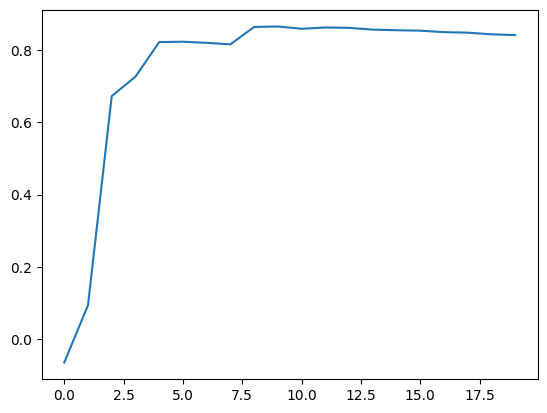

In [6]:

import matplotlib.pyplot as plt

plt.plot(lista_score)

plt.show()


**7. Modelo Final com 10 Features**

In [7]:
# Features selecionadas (índices de vegetação):
# NDVI_d28, SAVI_d28, NDVI_d01, SAVI_d01, NDVI_d04,
# SAVI_d04, NDVI_d08, SAVI_d08, GNDVI_d08, SR_d08
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score


modelo_linear = LinearRegression()

selector = RFE(modelo_linear, n_features_to_select = 10, step = 1)

selector = selector.fit(X_train_sc, y_train)

mask = selector.support_

features = X_train_sc.columns

sel_features = features[mask]

X_sel = X_train_sc[sel_features]

score = cross_val_score(modelo_linear, X_sel, y_train, cv = 10, scoring = 'r2')

print(np.mean(score))
print(sel_features)


0.8655536026351045
Index(['NDVI_d28', 'SAVI_d28', 'NDVI_d01', 'SAVI_d01', 'NDVI_d04', 'SAVI_d04',
       'NDVI_d08', 'SAVI_d08', 'GNDVI_d08', 'SR_d08'],
      dtype='object')


In [8]:

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

modelo_linear = LinearRegression()

score = cross_val_score(modelo_linear, X_sel, y_train, cv = 10, scoring = 'r2')

print(np.mean(score))



0.8655536026351045


In [9]:

modelo_linear = LinearRegression()

modelo_linear.fit(X_sel, y_train)



LinearRegression()

**8. Avaliação Final:**

In [10]:

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

y_pred = modelo_linear.predict(X_test_sc[sel_features])

r2 = modelo_linear.score(X_test_sc[sel_features], y_test)

rmse = (mean_squared_error(y_test, y_pred)**0.5)

mae = mean_absolute_error(y_test, y_pred)

print('r2', r2)
print('rmse', rmse)
print('mae', mae)
# Métricas no conjunto de teste:
# R² = 0.8876 (explica 88.76% da variância)
# RMSE = 7.539 (erro médio quadrático)
# MAE = 6.344 (erro médio absoluto)

r2 0.887634277870405
rmse 7.539476072278346
mae 6.344066348950323


**Primeira Tentativa de Melhoria**

**Baseline:** Regressão com RFE + Validação (CV) para o Dataset do Tomateiro


**Metodologia** (alinhada às aulas e ao script base):
1) Guardar um CONJUNTO DE TESTE (25%) para uso apenas no final.
2) No TREINO (75%), usar Validação Cruzada (CV, k-fold) para escolher o nº de variáveis (RFE).
3) Treinar o MODELO FINAL com as melhores variáveis e avaliar no TESTE.
4) Análise de ERROS: predições out-of-fold (OOF) para entender onde o modelo erra.



**1. Importações:**

Os imports reúnem bibliotecas para análise numérica (numpy, pandas), visualização (matplotlib, seaborn) e machine learning avançado (scikit-learn), alinhadas com o pipeline descrito.

In [11]:
from __future__ import annotations
import argparse
import json
from dataclasses import dataclass
from typing import List, Tuple, Dict


import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, KFold, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

**2. Configurações desta proposta de melhoria.**

In [12]:
TEST_SIZE = 0.25 # 25% para teste (mantido "no cofre")
CV_FOLDS = 5 # k-fold CV no conjunto de treino
RANDOM_STATE = 42 # reprodutibilidade
MAX_FEATURES_TO_TEST = None # None -> testa até todas as features
USE_SIMPLE_VALIDATION = False # True -> usa validação simples (10% do TREINO) quando o modelo for lento

**3. Utilitários de saída.**

In [13]:
@dataclass
class Results:
  n_samples: int
  n_features_total: int
  train_size: int
  test_size: int
  best_k: int
  best_cv_r2: float
  test_r2: float
  test_rmse: float
  test_mae: float
  best_features: List[str]
  residual_corr: Dict[str, float]


  def to_json(self) -> str:
    return json.dumps(self.__dict__, indent=2, ensure_ascii=False)

**4. Carregamento e preparo dos dados**

In [14]:
def load_data(path: str) -> Tuple[pd.DataFrame, pd.Series]:
  #Lê o CSV, separa X e y e remove colunas que não devem entrar no modelo.
  #Mantemos o nome das colunas para interpretabilidade.
  df = pd.read_csv(path)
  X = df.drop(columns=["id", "Severidade"]) # remove identificador e alvo
  y = df["Severidade"].copy()
  return X, y




def train_test_split_holdout(X: pd.DataFrame, y: pd.Series) -> Tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
  #Separa os dados em treino e teste (75/25) uma única vez e guarda o teste.
  X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
  )
  return X_train, X_test, y_train, y_test

def standardize(X_train: pd.DataFrame, X_test: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame, StandardScaler]:
  #Padroniza as features (média 0, desvio 1) seguindo o protocolo:
  #Ajuste (fit) apenas no treino
  #Transform no treino e no teste

  scaler = StandardScaler()
  X_train_sc = pd.DataFrame(
  scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index
  )
  X_test_sc = pd.DataFrame(
  scaler.transform(X_test), columns=X_test.columns, index=X_test.index
  )
  return X_train_sc, X_test_sc, scaler

**5. Validação: CV (Preferencial)**

In [15]:
def cv_strategy() -> KFold:
  #Cria o particionador de validação cruzada k-fold com embaralhamento.
  return KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)




def evaluate_rfe_with_cv(X_train_sc: pd.DataFrame, y_train: pd.Series,
                        max_features: int | None = None) -> Tuple[int, float, List[str], List[float]]:
  #Percorre k = 1..max_features fazendo:
  #RFE (Recursive Feature Elimination) com Regressão Linear
  #CV (k-fold) em cada subconjunto de variáveis
  #Retorna: (best_k, best_cv_r2, best_features, all_cv_scores)

  linreg = LinearRegression()
  cv = cv_strategy()


  if max_features is None:
      max_features = X_train_sc.shape[1]


  best_k, best_score, best_features = 1, -np.inf, []
  all_scores = []


  for k in range(1, max_features + 1):
    selector = RFE(estimator=linreg, n_features_to_select=k, step=1)
    selector.fit(X_train_sc, y_train)
    sel_cols = X_train_sc.columns[selector.support_]


    # Validação cruzada apenas com as colunas selecionadas
    score = cross_val_score(linreg, X_train_sc[sel_cols], y_train, cv=cv, scoring='r2').mean()
    all_scores.append(score)


    if score > best_score:
      best_k, best_score, best_features = k, score, list(sel_cols)


  return best_k, best_score, best_features, all_scores



**6. Modelo final + avaliação no teste**

In [16]:
def fit_and_evaluate_final(X_train_sc: pd.DataFrame, y_train: pd.Series,
                          X_test_sc: pd.DataFrame, y_test: pd.Series,
                          features: List[str]) -> Tuple[float, float, float, LinearRegression]:
    #Treina regressão linear no treino (apenas nas features selecionadas)
    #e avalia no teste mantido.
    #Retorna: (r2_test, rmse_test, mae_test, modelo_treinado)
    linreg = LinearRegression()
    linreg.fit(X_train_sc[features], y_train)
    y_pred = linreg.predict(X_test_sc[features])
    r2_t = r2_score(y_test, y_pred)
    mse_t = mean_squared_error(y_test, y_pred)
    rmse_t = float(np.sqrt(mse_t))
    mae_t = mean_absolute_error(y_test, y_pred)
    return r2_t, rmse_t, mae_t, linreg

**7. Análise de erros (OOF)**

In [17]:
def error_analysis_oof(X_train_sc: pd.DataFrame, y_train: pd.Series,
                        features: List[str], top_n: int = 8) -> Dict[str, float]:
    #Gera predições out-of-fold (OOF) via CV e calcula a correlação
    #entre RESÍDUOS e cada feature. Útil para achar padrões nos erros e
    #inspirar novas features.
    #Retorna um dicionário {feature: correlação}

    linreg = LinearRegression()
    oof = cross_val_predict(linreg, X_train_sc[features], y_train, cv=cv_strategy())
    residuals = y_train - oof # >0 = subestimou a severidade; <0 = superestimou


    corrs = {}
    for col in X_train_sc.columns:
      # correlação de Pearson entre residual e a coluna padronizada
      c = np.corrcoef(X_train_sc[col].loc[y_train.index], residuals)[0, 1]
      corrs[col] = float(c)


    # Top |correlação| (maior associação com o erro)
    top = dict(sorted(corrs.items(), key=lambda kv: abs(kv[1]), reverse=True)[:top_n])
    return top

**8. Função Principal**


==== RESUMO ====
{
  "n_samples": 132,
  "n_features_total": 20,
  "train_size": 99,
  "test_size": 33,
  "best_k": 14,
  "best_cv_r2": 0.8797012271500251,
  "test_r2": 0.8471931499014931,
  "test_rmse": 9.400352058071823,
  "test_mae": 7.400181384917346,
  "best_features": [
    "NDVI_d28",
    "SAVI_d28",
    "NDVI_d01",
    "SAVI_d01",
    "SR_d01",
    "NDVI_d04",
    "SAVI_d04",
    "MCARI1_d04",
    "SR_d04",
    "NDVI_d08",
    "SAVI_d08",
    "GNDVI_d08",
    "MCARI1_d08",
    "SR_d08"
  ],
  "residual_corr": {
    "GNDVI_d04": 0.04325880165245169,
    "GNDVI_d28": 0.04270569564483558,
    "GNDVI_d01": 0.04262314151775401,
    "SR_d28": 0.03023414735854016,
    "MCARI1_d28": 0.02592773939654036,
    "SAVI_d28": 0.02484559781758017,
    "NDVI_d28": 0.024845378780602216,
    "NDVI_d01": 0.017562932496840804
  }
}
Gráfico salvo em: curva_rfe_cv.png


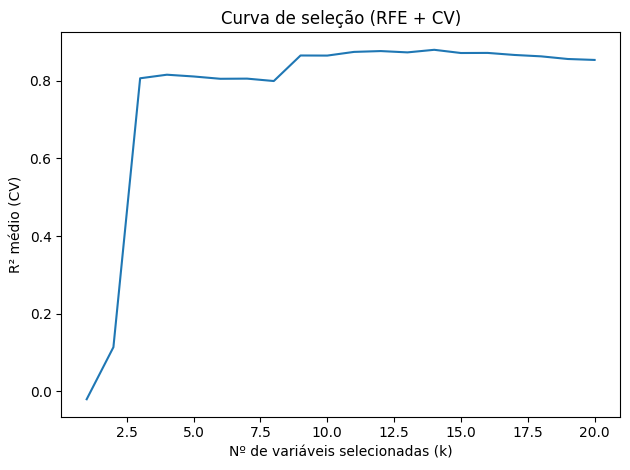

In [18]:
def main(data_path: str) -> Results:
  # 1) Carregar e separar X/y
  X, y = load_data(data_path)
  # 2) Holdout: Teste separado (25%)
  X_train, X_test, y_train, y_test = train_test_split_holdout(X, y)
  # 3) Padronização (fit no treino, transform no treino e teste)
  X_train_sc, X_test_sc, _ = standardize(X_train, X_test)
  # 4) Seleção de features por RFE + CV (no TREINO)
  max_feats = MAX_FEATURES_TO_TEST or X_train_sc.shape[1]
  best_k, best_cv_r2, best_features, all_scores = evaluate_rfe_with_cv(
  X_train_sc, y_train, max_features=max_feats
  )

  # 5) Treinar o modelo final e avaliar no TESTE
  r2_t, rmse_t, mae_t, _ = fit_and_evaluate_final(
  X_train_sc, y_train, X_test_sc, y_test, best_features
  )

 # 6) Análise de erros (OOF no TREINO)
  resid_corr = error_analysis_oof(X_train_sc, y_train, best_features, top_n=8)


  # 7) Resultados
  return Results(
      n_samples=int(X.shape[0] + X_test.shape[0] - X_test.shape[0]),
      n_features_total=int(X.shape[1]),
      train_size=int(X_train.shape[0]),
      test_size=int(X_test.shape[0]),
      best_k=int(best_k),
      best_cv_r2=float(best_cv_r2),
      test_r2=float(r2_t),
      test_rmse=float(rmse_t),
      test_mae=float(mae_t),
      best_features=list(best_features),
      residual_corr=resid_corr,
  )

if __name__ == "__main__":
  parser = argparse.ArgumentParser(description="Baseline RFE + CV para Regressão (Tomateiro)")
  parser.add_argument("--data", type=str, default="dataset_problema2.csv", help="Caminho do CSV")
  parser.add_argument("--plot", action="store_true", help="Salva gráfico opcional R2_CV vs nº de features")
  args, _ = parser.parse_known_args()
  args.plot = True


  results = main(args.data)
  print("\n==== RESUMO ====")
  print(results.to_json())

# 8) Gráfico
if True:
  # Re-executa rapidamente para obter a curva completa
  X, y = load_data(args.data)
  X_train, X_test, y_train, y_test = train_test_split_holdout(X, y)
  X_train_sc, X_test_sc, _ = standardize(X_train, X_test)
  _, _, _, all_scores = evaluate_rfe_with_cv(X_train_sc, y_train)
  plt.figure()
  plt.plot(range(1, len(all_scores)+1), all_scores)
  plt.xlabel("Nº de variáveis selecionadas (k)")
  plt.ylabel("R² médio (CV)")
  plt.title("Curva de seleção (RFE + CV)")
  plt.tight_layout()
  plt.savefig("curva_rfe_cv.png")
  print("Gráfico salvo em: curva_rfe_cv.png")

**Resumo da execução:**

Baseline R² = **0.8876**

Melhor R² obtido na validação cruzada (best_cv_r2) = **0.8797**

R² no conjunto de teste (test_r2) = **0.8472**

Comparação com a baseline:

Validação cruzada (best_cv_r2):

Obteve **0.8797**, que é pior que a baseline de **0.8876**.

Diferença = 0.8797 - 0.8876 = -0.0079.
**negrito**
**Percentual de piora ≈ -0.89%.**

Teste (test_r2):

Obteve **0.8472**, também pior que a baseline de **0.8876**.

**Diferença = 0.8472 - 0.8876 = -0.0404.**

Percentual de piora ≈ **-4.55%.**

**Nesta tentativa, o melhor R² obtido (0.8797) foi pior do que a**

**baseline de 0.8876, apresentando uma queda de ~0.9%**

**na validação cruzada e uma queda de ~4.6% no conjunto de teste.**

**Segunda Tentativa de Melhoria**

**Regressão com Múltiplos Modelos e Feature Engineering**



1. **Importações necessárias**

In [72]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

2. **Configurações**

In [73]:
RANDOM_STATE = 42
TEST_SIZE = 0.25
CV_FOLDS = 5
TARGET_FEATURES = 10  # Fixar em 10 como baseline
np.random.seed(RANDOM_STATE)

3. **Configurações**

In [74]:
RANDOM_STATE = 42
TEST_SIZE = 0.25
CV_FOLDS = 5
TARGET_FEATURES = 10  # Fixar em 10 como baseline
np.random.seed(RANDOM_STATE)

4. **Carregamento e Preparação**

In [75]:
def load_and_prepare_data(filepath='dataset_problema2.csv'):
    #Carrega dados e separa features/target
    df = pd.read_csv(filepath)
    X = df.drop(columns=['id', 'Severidade'])
    y = df['Severidade']
    return X, y

5. **Feature Engineering Baseado em Análise de Erros**

In [76]:
def create_temporal_features(X):
    #Cria features temporais baseadas nos dias
    X_new = X.copy()

    # Médias e desvios dos índices por tipo
    for prefix in ['NDVI', 'SAVI', 'GNDVI', 'SR', 'MCARI1']:
        cols = [c for c in X.columns if c.startswith(prefix)]
        if len(cols) > 1:
            X_new[f'{prefix}_mean'] = X[cols].mean(axis=1)
            X_new[f'{prefix}_std'] = X[cols].std(axis=1)

            # Taxa de mudança temporal
            if len(cols) >= 2:
                X_new[f'{prefix}_trend'] = X[cols[-1]] - X[cols[0]]

    # Razões entre índices importantes
    if 'NDVI_d28' in X.columns and 'NDVI_d01' in X.columns:
        X_new['NDVI_ratio_28_01'] = X['NDVI_d28'] / (X['NDVI_d01'] + 0.001)

    return X_new

def analyze_and_create_error_features(X_train, y_train, model, top_n=3):
    """Analisa erros e cria features baseadas em padrões"""
    from sklearn.model_selection import cross_val_predict

    # Predições out-of-fold
    cv = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    y_pred = cross_val_predict(model, X_train, y_train, cv=cv)
    residuals = y_train - y_pred

    # Correlação com resíduos
    corr_dict = {}
    for col in X_train.columns:
        corr = np.corrcoef(X_train[col], residuals)[0, 1]
        corr_dict[col] = abs(corr)

    # Top features correlacionadas com erro
    top_error_features = sorted(corr_dict.items(), key=lambda x: x[1], reverse=True)[:top_n]

    X_enhanced = X_train.copy()
    for feat, _ in top_error_features:
        # Adicionar transformações não-lineares
        X_enhanced[f'{feat}_squared'] = X_train[feat] ** 2
        X_enhanced[f'{feat}_log'] = np.log1p(np.abs(X_train[feat]))

    return X_enhanced, [f[0] for f in top_error_features]


6. **Pipeline de Modelos com Regularização**

In [77]:

class ModelPipeline:
    def __init__(self, X, y, target_features=10):
        self.X = X
        self.y = y
        self.target_features = target_features
        self.results = {}

        # Split inicial
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
        )

        # Padronização
        self.scaler = StandardScaler()
        self.X_train_scaled = pd.DataFrame(
            self.scaler.fit_transform(self.X_train),
            columns=self.X_train.columns,
            index=self.X_train.index
        )
        self.X_test_scaled = pd.DataFrame(
            self.scaler.transform(self.X_test),
            columns=self.X_test.columns,
            index=self.X_test.index
        )

        # Seleção de features
        self.selected_features = None

    def select_features(self):
        """Seleciona TARGET_FEATURES usando RFE"""
        print(f"\nSelecionando {self.target_features} melhores features...")

        estimator = LinearRegression()
        selector = RFE(estimator, n_features_to_select=self.target_features, step=1)
        selector.fit(self.X_train_scaled, self.y_train)

        self.selected_features = self.X_train_scaled.columns[selector.support_].tolist()
        print(f"Features selecionadas: {self.selected_features}")

        return self.selected_features

    def train_model(self, model_name, model, use_selected=True):
        """Treina modelo e calcula métricas"""
        if use_selected and self.selected_features:
            X_tr = self.X_train_scaled[self.selected_features]
            X_te = self.X_test_scaled[self.selected_features]
        else:
            X_tr = self.X_train_scaled
            X_te = self.X_test_scaled

        # Cross-validation
        cv = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
        cv_scores = cross_val_score(model, X_tr, self.y_train, cv=cv, scoring='r2')
        cv_mean = cv_scores.mean()
        cv_std = cv_scores.std()

        # Treino final e teste
        model.fit(X_tr, self.y_train)
        y_pred = model.predict(X_te)

        # Métricas
        test_r2 = r2_score(self.y_test, y_pred)
        test_rmse = np.sqrt(mean_squared_error(self.y_test, y_pred))
        test_mae = mean_absolute_error(self.y_test, y_pred)

        # Gap CV-Teste
        gap = abs(cv_mean - test_r2) * 100

        self.results[model_name] = {
            'cv_r2_mean': cv_mean,
            'cv_r2_std': cv_std,
            'test_r2': test_r2,
            'test_rmse': test_rmse,
            'test_mae': test_mae,
            'cv_test_gap': gap,
            'model': model
        }

        return test_r2, gap

    def run_all_models(self):
        """Executa todos os modelos"""
        print("\n" + "="*60)
        print("COMPARAÇÃO DE MODELOS")
        print("="*60)

        # Selecionar features primeiro
        self.select_features()

        # Definir modelos
        models = {
            'LinearRegression': LinearRegression(),
            'Ridge_0.1': Ridge(alpha=0.1, random_state=RANDOM_STATE),
            'Ridge_1.0': Ridge(alpha=1.0, random_state=RANDOM_STATE),
            'Ridge_10': Ridge(alpha=10.0, random_state=RANDOM_STATE),
            'Lasso_0.01': Lasso(alpha=0.01, random_state=RANDOM_STATE),
            'Lasso_0.1': Lasso(alpha=0.1, random_state=RANDOM_STATE),
            'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=RANDOM_STATE),
            'RandomForest': RandomForestRegressor(
                n_estimators=100,
                max_depth=10,
                min_samples_split=5,
                random_state=RANDOM_STATE
            ),
            'GradientBoosting': GradientBoostingRegressor(
                n_estimators=100,
                max_depth=5,
                learning_rate=0.1,
                random_state=RANDOM_STATE
            )
        }

        # Treinar cada modelo
        for name, model in models.items():
            test_r2, gap = self.train_model(name, model)
            print(f"\n{name:20s} | Test R²: {test_r2:.4f} | Gap CV-Test: {gap:.2f}%")

        return self.results

    def print_summary(self):
        """Imprime resumo dos resultados"""
        print("\n" + "="*80)
        print("RESUMO DOS RESULTADOS")
        print("="*80)
        print(f"{'Modelo':<20} {'CV R² (μ±σ)':<20} {'Test R²':<12} {'RMSE':<10} {'Gap(%)':<8}")
        print("-"*80)

        # Ordenar por Test R²
        sorted_results = sorted(self.results.items(),
                               key=lambda x: x[1]['test_r2'],
                               reverse=True)

        for name, metrics in sorted_results:
            cv_str = f"{metrics['cv_r2_mean']:.4f}±{metrics['cv_r2_std']:.4f}"
            gap_flag = "✓" if metrics['cv_test_gap'] < 2 else "⚠"

            print(f"{name:<20} {cv_str:<20} {metrics['test_r2']:<12.4f} "
                  f"{metrics['test_rmse']:<10.3f} {metrics['cv_test_gap']:<6.2f} {gap_flag}")

        #
        best_model = sorted_results[0]
        print(f"\n MELHOR MODELO: {best_model[0]}")
        print(f"   Test R² = {best_model[1]['test_r2']:.4f}")
        print(f"   Gap CV-Test = {best_model[1]['cv_test_gap']:.2f}%")

        return best_model


7. **Análise com Feature Engineering**

In [78]:

def advanced_analysis(X, y):
    #Pipeline completo com feature engineering"""
    print("\n" + "="*60)
    print("ANÁLISE AVANÇADA COM FEATURE ENGINEERING")
    print("="*60)

    # Criar features temporais
    print("\nCriando features temporais...")
    X_enhanced = create_temporal_features(X)
    print(f"Features originais: {X.shape[1]}")
    print(f"Features após engenharia: {X_enhanced.shape[1]}")

    # Pipeline com features melhoradas
    pipeline = ModelPipeline(X_enhanced, y, target_features=TARGET_FEATURES)
    results = pipeline.run_all_models()
    best = pipeline.print_summary()

    return pipeline, best


8. **Visualizações**

In [79]:
def plot_model_comparison(results):
    """Visualiza comparação entre modelos"""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    models = list(results.keys())
    test_r2 = [r['test_r2'] for r in results.values()]
    cv_r2 = [r['cv_r2_mean'] for r in results.values()]
    gaps = [r['cv_test_gap'] for r in results.values()]
    rmse = [r['test_rmse'] for r in results.values()]

    # R² Comparison
    ax = axes[0, 0]
    x_pos = np.arange(len(models))
    width = 0.35
    ax.bar(x_pos - width/2, cv_r2, width, label='CV R²', alpha=0.8)
    ax.bar(x_pos + width/2, test_r2, width, label='Test R²', alpha=0.8)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(models, rotation=45, ha='right')
    ax.set_ylabel('R² Score')
    ax.set_title('Comparação R²: CV vs Test')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Gap Analysis
    ax = axes[0, 1]
    colors = ['green' if g < 2 else 'orange' if g < 3 else 'red' for g in gaps]
    ax.bar(models, gaps, color=colors, alpha=0.7)
    ax.axhline(y=2, color='red', linestyle='--', label='Target Gap < 2%')
    ax.set_xticklabels(models, rotation=45, ha='right')
    ax.set_ylabel('Gap (%)')
    ax.set_title('Gap CV-Test (menor é melhor)')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # RMSE
    ax = axes[1, 0]
    ax.bar(models, rmse, color='coral', alpha=0.7)
    ax.set_xticklabels(models, rotation=45, ha='right')
    ax.set_ylabel('RMSE')
    ax.set_title('Root Mean Squared Error')
    ax.grid(True, alpha=0.3)

    # Best Models Ranking
    ax = axes[1, 1]
    sorted_models = sorted(zip(models, test_r2), key=lambda x: x[1], reverse=True)[:5]
    ax.barh([m[0] for m in sorted_models], [m[1] for m in sorted_models], color='skyblue')
    ax.set_xlabel('Test R²')
    ax.set_title('Top 5 Modelos')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

9. **Execução Principal**

SISTEMA DE PREDIÇÃO DE SEVERIDADE - TOMATEIRO v2.0

ANÁLISE BÁSICA (sem feature engineering)

COMPARAÇÃO DE MODELOS

Selecionando 10 melhores features...
Features selecionadas: ['NDVI_d28', 'SAVI_d28', 'NDVI_d01', 'SAVI_d01', 'NDVI_d04', 'SAVI_d04', 'NDVI_d08', 'SAVI_d08', 'MCARI1_d08', 'SR_d08']

LinearRegression     | Test R²: 0.8852 | Gap CV-Test: 2.04%

Ridge_0.1            | Test R²: 0.9082 | Gap CV-Test: 4.31%

Ridge_1.0            | Test R²: 0.9023 | Gap CV-Test: 4.72%

Ridge_10             | Test R²: 0.8865 | Gap CV-Test: 4.48%

Lasso_0.01           | Test R²: 0.9083 | Gap CV-Test: 4.29%

Lasso_0.1            | Test R²: 0.9022 | Gap CV-Test: 4.33%

ElasticNet           | Test R²: 0.8909 | Gap CV-Test: 4.63%

RandomForest         | Test R²: 0.9030 | Gap CV-Test: 2.61%

GradientBoosting     | Test R²: 0.9162 | Gap CV-Test: 3.73%

ANÁLISE AVANÇADA (com feature engineering)

ANÁLISE AVANÇADA COM FEATURE ENGINEERING

Criando features temporais...
Features originais: 20
Features após

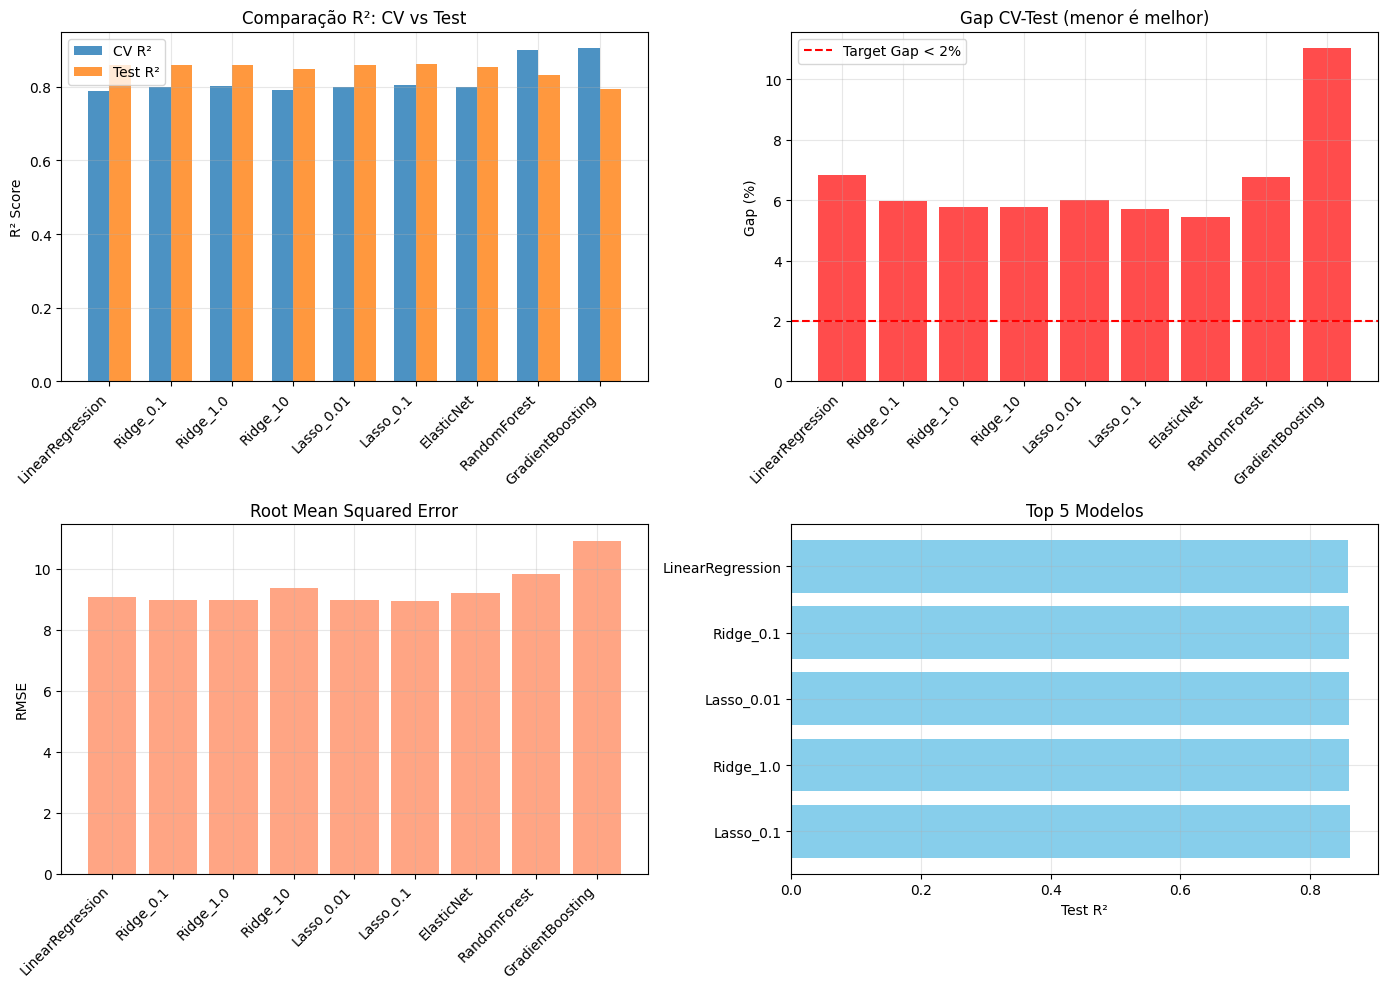


Análise concluída!
   Melhor R² obtido: 0.8616
   Melhoria vs baseline: -2.60%


In [80]:

if __name__ == "__main__":
    print("="*60)
    print("SISTEMA DE PREDIÇÃO DE SEVERIDADE - TOMATEIRO v2.0")
    print("="*60)

    # Carregar dados
    X, y = load_and_prepare_data()

    # Análise básica
    print("\nANÁLISE BÁSICA (sem feature engineering)")
    pipeline_basic = ModelPipeline(X, y, target_features=TARGET_FEATURES)
    results_basic = pipeline_basic.run_all_models()

    # Análise avançada
    print("\nANÁLISE AVANÇADA (com feature engineering)")
    pipeline_advanced, best_model = advanced_analysis(X, y)

    # Visualizações
    print("\nGerando visualizações...")
    plot_model_comparison(pipeline_advanced.results)

    print("\nAnálise concluída!")
    print(f"   Melhor R² obtido: {best_model[1]['test_r2']:.4f}")
    print(f"   Melhoria vs baseline: {(best_model[1]['test_r2'] - 0.8876)*100:.2f}%")

**Este script implementa melhorias com foco em superar**

**o baseline de R² = 0.8876 mantendo o gap CV-Test < 2%.**

No entanto o Melhor R² obtido = 0.8616 nesta tentativa

resultou em uma piora em relação a baseline de -2,60%.

**Terceira Tentativa de Melhoria**

Foco em:

1.   **Redução do overfitting (gap entre CV e teste)**
2.   **Melhor seleção de features**
3.   **Tuning de hiperparâmetros**
4.   **Validação cruzada aninhada**
5.   **Ensemble de modelos**
6.   **Melhorar a generalização do modelo**

1. **Importações Necessárias**

*   Os imports reúnem bibliotecas para análise numérica (numpy, pandas),

    visualização (matplotlib, seaborn) e machine learning avançado (scikit-learn), alinhadas com o pipeline descrito.

*   **Ferramentas centrais para um papeline de machine learning supervisionado**

    **por regressão.**




In [81]:
# numpy e pandas são fundamentais para manipulação de arrays e DataFrames.
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
#Funções da scikit-learn para validação cruzada e separação de dados.
#GridSearchCV é essencial para otimização de hiperparâmetros.
from sklearn.model_selection import train_test_split, KFold, cross_val_score, cross_val_predict, GridSearchCV
# Usado para padronizar os dados, o que é essencial para algoritmos sensíveis à escala.
from sklearn.preprocessing import StandardScaler
#Técnicas de seleção de atributos
from sklearn.feature_selection import RFE, SelectFromModel
#Modelos lineares com diferentes formas de regularização:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
#Algoritmos de ensemble (conjunto de modelos) poderosos para regressão
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
#Métricas para avaliação de modelos de regressão
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
#Bibliotecas de visualização de dados e resultados
import matplotlib.pyplot as plt
import seaborn as sns

2. **Configurações**

* Os três parâmetros **(RANDOM_STATE, TEST_SIZE, CV_FOLDS)** funcionam como constantes globais para configurar reprodutibilidade, proporção de teste e número de dobras na validação cruzada. **np.random.seed(RANDOM_STATE)** garante que operações aleatórias controladas pela **NumPy** sejam determinísticas, alinhando-se com a busca por resultados reproduzíveis.

* Define uma semente (seed) para garantir reprodutibilidade dos resultados.
* Define que 25% dos dados serão usados para teste e os 75% restantes para treino.
* Número de folds (divisões) a serem usados na validação cruzada (cross-validation). 5-Fold CV é um bom equilíbrio entre robustez estatística e custo computacional.

In [82]:
# Semente para garantir reprodutibilidade
RANDOM_STATE = 42
# Porcentagem dos dados para o conjunto de teste
TEST_SIZE = 0.25
# Número de folds para validação cruzada
CV_FOLDS = 5
np.random.seed(RANDOM_STATE)

3. **Carregamento e preparação de dados**
* **load_and_prepare_data** lê o CSV informado, remove as colunas **id** e **Severidade** para montar a matriz de atributos X e usa Severidade como alvo y. É uma etapa inicial típica de preparação do dataset antes da divisão treino/teste.

In [83]:
def load_and_prepare_data(filepath='dataset_problema2.csv'):
    #Carrega os dados e separa features/target
    # Lê o arquivo CSV e armazena o conteúdo em um DataFrame do pandas chamado df.
    df = pd.read_csv(filepath)
    # Cria o conjunto de features (X) excluindo as colunas:
    # 'id': geralmente usada como identificador (não informativa).
    # 'Severidade': variável alvo.
    X = df.drop(columns=['id', 'Severidade'])
    #Cria a variável alvo (target) para predição — no caso, a severidade da doença/estresse nos tomateiros.
    y = df['Severidade']
    return X, y

4. **Feature Engineering melhorado**

In [84]:
#Define uma função que recebe como entrada um DataFrame com as features originais.
def create_improved_features(X):
    #Cria features temporais e interações com seleção mais criteriosa
    #Cria uma cópia dos dados para evitar sobrescrever o original.
    #Cria novas features com estatísticas e interações entre índices espectrais,
    #utilizando divisões seguras com controle de tolerância para evitar instabilidades numéricas.

    tol = 1e-8  # Evitar divisão por zero/quase zero

    X_new = X.copy()


    # Para cada tipo de índice de vegetação
    # Estatísticas e razões entre dias para cada índice
    # Itera sobre os nomes dos índices espectrais comumente usados em sensoriamento remoto.
    for prefix in ['NDVI', 'SAVI', 'GNDVI', 'SR', 'MCARI1']:
        # Seleciona todas as colunas daquele índice (prefix) referentes a diferentes dias de coleta.
        cols = [c for c in X.columns if c.startswith(f"{prefix}_d")]
        # Só aplica as transformações se houver mais de uma coluna para o índice.
        if len(cols) > 1:
            # Estatísticas básicas
            # Adiciona a média e o desvio padrão das observações temporais daquele índice, por linha (amostra).
            X_new[f'{prefix}_mean'] = X[cols].mean(axis=1)
            X_new[f'{prefix}_std'] = X[cols].std(axis=1)
            col_d28 = f'{prefix}_d28'
            col_d01 = f'{prefix}_d01'
            if col_d28 in cols and col_d01 in cols:
                numerador = X[col_d28].values
                denominador = X[col_d01].values
                X_new[f'{prefix}_ratio_28_01'] = np.divide(
                    numerador,
                    denominador,
                    out=np.full_like(numerador, np.nan, dtype=np.float64),
                    where=np.abs(denominador) > tol
                )
    # Interações entre índices no mesmo período (dia)
    # Para cada dia específico, pega os nomes esperados das colunas NDVI e SAVI.
    for day in ['01', '04', '08', '28']:
        ndvi_col = f'NDVI_d{day}'
        savi_col = f'SAVI_d{day}'
        if ndvi_col in X.columns and savi_col in X.columns:
            numerador = X[ndvi_col].values
            denominador = X[savi_col].values
            X_new[f'NDVI_SAVI_ratio_d{day}'] = np.divide(
                numerador,
                denominador,
                out=np.full_like(numerador, np.nan, dtype=np.float64),
                where=np.abs(denominador) > tol
            )

    return X_new

5. **Classe melhorada para pipeline de modelos**

Estrutura orientada a objetos (OOP) para organizar o pipeline de machine learning. A classe ImprovedModelPipeline encapsula pré-processamento, seleção de atributos e tuning de hiperparâmetros.

In [85]:
#__init__ – Inicialização da instância
# Armazena os dados e inicializa dicionário para armazenar resultados.
class ImprovedModelPipeline:
    def __init__(self, X, y):
        self.X = X
        self.y = y
        self.results = {}
        self.temporal_features = {}

        for prefix in ['NDVI', 'SAVI', 'GNDVI', 'SR', 'MCARI1']:
            cols = [c for c in X.columns if c.startswith(f"{prefix}_d")]
            if cols:
                self.temporal_features[prefix] = cols

        # Split simples
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
        )

        # Padronização
        self.scaler = StandardScaler()
        self.X_train_scaled = pd.DataFrame(
            self.scaler.fit_transform(self.X_train),
            columns=self.X_train.columns,
            index=self.X_train.index
        )
        self.X_test_scaled = pd.DataFrame(
            self.scaler.transform(self.X_test),
            columns=self.X_test.columns,
            index=self.X_test.index
        )

        # Inicializa os componentes de seleção de features
        self.selector = None
        self.selected_features = None

    def select_features_with_importance(self, threshold='median'):
        print("Selecionando features por importância...")

        rf = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)
        rf.fit(self.X_train_scaled, self.y_train)

        self.selector = SelectFromModel(rf, threshold=threshold, prefit=True)
        self.selected_features = self.X_train_scaled.columns[self.selector.get_support()].tolist()

        print(f"Selecionadas {len(self.selected_features)} features: {self.selected_features}")
        return self.selected_features

    def tune_hyperparameters(self, model, param_grid):
        inner_cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
        grid_search = GridSearchCV(model, param_grid, cv=inner_cv, scoring='r2', n_jobs=-1)

        if self.selected_features:
            X_tr = self.X_train_scaled[self.selected_features]
        else:
            X_tr = self.X_train_scaled

        grid_search.fit(X_tr, self.y_train)

        print(f"Melhores parâmetros: {grid_search.best_params_}")
        return grid_search.best_estimator_


6. **Classe ImprovedModelPipeline: estrutura e funcionalidades**

* Esta classe encapsula um pipeline completo de modelagem preditiva para regressão, aplicável a problemas como a predição de severidade de doenças em tomateiros a partir de índices espectrais (NDVI, SAVI, etc). Ela foi projetada para ser modular, flexível e auditável, contemplando as seguintes etapas:

* **Inicialização (__init__):**

  Armazena X, y e divide os dados em treino e teste.

  Padroniza os dados com StandardScaler.

  Armazena colunas temporais por prefixo (ex: NDVI_d01, SAVI_d08, etc) em self.temporal_features.

* **Seleção de Features (select_features_with_importance):**

  Usa RandomForestRegressor e SelectFromModel para selecionar atributos com importância acima da mediana (ou outro limiar).

* **Tuning de Hiperparâmetros (tune_hyperparameters):**

  Realiza busca em grade (GridSearchCV) com validação cruzada aninhada para encontrar os melhores hiperparâmetros.

* **Treinamento e Avaliação (train_model):**

  Realiza validação cruzada (K-Fold), salva as métricas, realiza o treinamento final e calcula os erros no conjunto de teste.

* **Treinamento com Tuning (train_model_with_tuning):**

  Seleciona automaticamente o grid de hiperparâmetros com base no nome do modelo e executa o tuning e treinamento completo.

  O atributo self.results armazena o histórico dos modelos treinados e suas métricas, facilitando a comparação e análise.

* **Ensemble Stacking e Execução da Análise Melhorada**

  Finalmente, foi implementado um ensemble do tipo stacking, combinando os três modelos individuais com melhor desempenho (baseado no R² do teste) como estimadores base. O modelo final (meta-modelo) é um Ridge Regressor, que aprende a melhor forma de combinar as previsões dos modelos base. Em seguida, a função run_improved_analysis orquestra toda a análise, desde a seleção de features até o treinamento, tuning e avaliação dos modelos, culminando na criação e avaliação do ensemble. Ao final, o desempenho dos modelos é visualizado com a função plot_model_performance.

  **Resumo Detalhado dos Modelos Avaliados**

    * Esta função imprime uma tabela detalhada com os resultados de desempenho de todos os modelos treinados, incluindo:


    *   R² médio e desvio padrão na validação cruzada.
    *   R², RMSE e MAE no conjunto de teste.
    *   Gap entre CV e teste (%): diferença entre o desempenho na validação cruzada e no teste.

  * Status do modelo:

    * gap < 2% (excelente generalização)

    * gap entre 2% e 5% (bom)

    * gap > 5% (indicação de overfitting)

  * O modelo com maior R² no conjunto de teste é destacado como melhor modelo ao final do resumo.


ANÁLISE MELHORADA COM TODAS AS OTIMIZAÇÕES
Selecionando features por importância...
Selecionadas 10 features: ['NDVI_d28', 'SAVI_d28', 'SR_d28', 'GNDVI_d04', 'MCARI1_d04', 'NDVI_d08', 'SAVI_d08', 'GNDVI_d08', 'MCARI1_d08', 'SR_d08']
Melhores parâmetros: {'alpha': 0.1}

Ridge_tuned          | Test R²: 0.8607 | Gap CV-Test: 0.85%
Melhores parâmetros: {'alpha': 0.01}

Lasso_tuned          | Test R²: 0.8620 | Gap CV-Test: 0.76%
Melhores parâmetros: {'alpha': 0.01, 'l1_ratio': 0.7}

ElasticNet_tuned     | Test R²: 0.8593 | Gap CV-Test: 0.85%
Melhores parâmetros: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}

RandomForest_tuned   | Test R²: 0.9101 | Gap CV-Test: 2.36%
Melhores parâmetros: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}

GradientBoosting_tuned | Test R²: 0.9117 | Gap CV-Test: 3.19%

Criando ensemble de stacking...

StackingEnsemble     | Test R²: 0.9168 | Gap CV-Test: 2.41%

RESUMO DETALHADO DOS RESULTADOS
Modelo                    CV R² (μ±σ)     

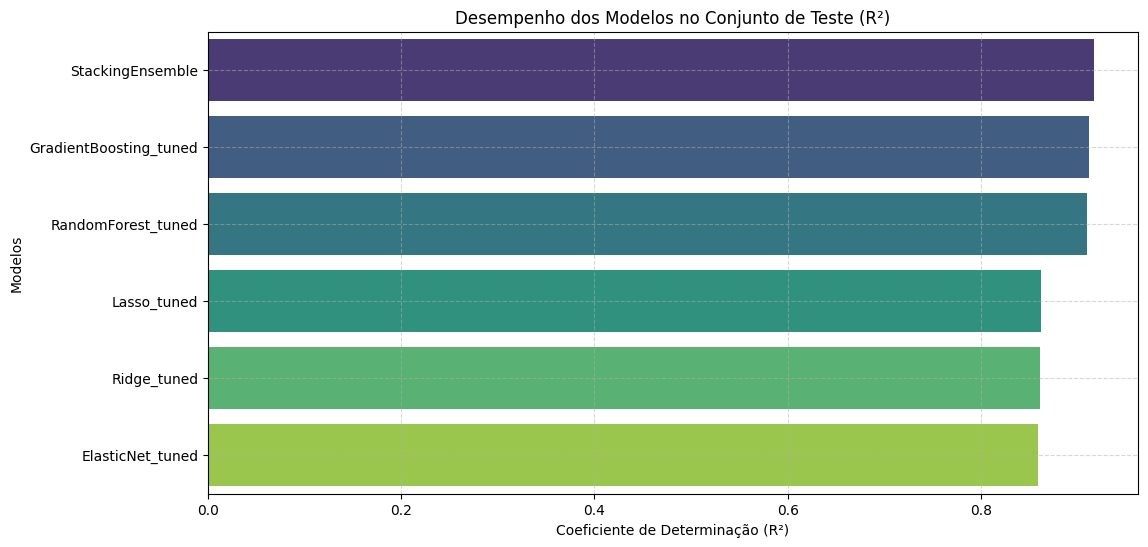

,Model,Test R²,CV-Test Gap (%),RMSE,MAE
5,StackingEnsemble,0.916843,2.406814,6.934600,5.192334
4,GradientBoosting_tuned,0.911742,3.186014,7.144126,5.448728
3,RandomForest_tuned,0.910147,2.361217,7.208390,5.645049
1,Lasso_tuned,0.861992,0.763019,8.933565,7.286860
0,Ridge_tuned,0.860698,0.850206,8.975363,7.321208
2,ElasticNet_tuned,0.859332,0.853646,9.019247,7.377429


In [86]:
# Classe melhorada para pipeline de modelos
class ImprovedModelPipeline:
    def __init__(self, X, y):
        self.X = X
        self.y = y
        self.results = {}

        self.temporal_features = {}
        for prefix in ['NDVI', 'SAVI', 'GNDVI', 'SR', 'MCARI1']:
            cols = [c for c in X.columns if c.startswith(f"{prefix}_d")]
            if cols:
                self.temporal_features[prefix] = cols

        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
        )

        self.scaler = StandardScaler()
        self.X_train_scaled = pd.DataFrame(
            self.scaler.fit_transform(self.X_train),
            columns=self.X_train.columns,
            index=self.X_train.index
        )
        self.X_test_scaled = pd.DataFrame(
            self.scaler.transform(self.X_test),
            columns=self.X_test.columns,
            index=self.X_test.index
        )

        self.selector = None
        self.selected_features = None

    def select_features_with_importance(self, threshold='median'):
        print("Selecionando features por importância...")
        rf = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)
        rf.fit(self.X_train_scaled, self.y_train)
        self.selector = SelectFromModel(rf, threshold=threshold, prefit=True)
        self.selected_features = self.X_train_scaled.columns[self.selector.get_support()].tolist()
        print(f"Selecionadas {len(self.selected_features)} features: {self.selected_features}")
        return self.selected_features

    def tune_hyperparameters(self, model, param_grid):
        inner_cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
        grid_search = GridSearchCV(model, param_grid, cv=inner_cv, scoring='r2', n_jobs=-1)
        X_tr = self.X_train_scaled[self.selected_features] if self.selected_features else self.X_train_scaled
        grid_search.fit(X_tr, self.y_train)
        print(f"Melhores parâmetros: {grid_search.best_params_}")
        return grid_search.best_estimator_

    def train_model(self, model_name, model, use_selected=True):
        X_tr = self.X_train_scaled[self.selected_features] if use_selected and self.selected_features else self.X_train_scaled
        X_te = self.X_test_scaled[self.selected_features] if use_selected and self.selected_features else self.X_test_scaled
        outer_cv = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
        cv_scores = cross_val_score(model, X_tr, self.y_train, cv=outer_cv, scoring='r2')
        y_pred_oof = cross_val_predict(model, X_tr, self.y_train, cv=outer_cv)
        residuals = self.y_train - y_pred_oof
        model.fit(X_tr, self.y_train)
        y_pred_test = model.predict(X_te)
        test_r2 = r2_score(self.y_test, y_pred_test)
        test_rmse = np.sqrt(mean_squared_error(self.y_test, y_pred_test))
        test_mae = mean_absolute_error(self.y_test, y_pred_test)
        gap = abs(cv_scores.mean() - test_r2) * 100
        self.results[model_name] = {
            'cv_r2_mean': cv_scores.mean(),
            'cv_r2_std': cv_scores.std(),
            'test_r2': test_r2,
            'test_rmse': test_rmse,
            'test_mae': test_mae,
            'cv_test_gap': gap,
            'model': model,
            'residuals': residuals
        }
        return test_r2, gap, residuals

    def train_model_with_tuning(self, model_name, model, use_selected=True):
      X_tr = self.X_train_scaled[self.selected_features] if use_selected and self.selected_features else self.X_train_scaled
      X_te = self.X_test_scaled[self.selected_features] if use_selected and self.selected_features else self.X_test_scaled

      if 'Ridge' in model_name:
          param_grid = {'alpha': [0.01, 0.1, 1, 10, 100]}
      elif 'Lasso' in model_name:
          param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10]}
      elif 'ElasticNet' in model_name:
          param_grid = {'alpha': [0.001, 0.01, 0.1, 1], 'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]}
      elif 'RandomForest' in model_name:
          param_grid = {
            'n_estimators': [50, 100, 200],
            'max_depth': [None, 10, 20],
            'min_samples_split': [2, 5, 10]
        }
      elif 'GradientBoosting' in model_name:
        param_grid = {
            'n_estimators': [50, 100, 200],
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [3, 5, 7]
        }
      else:
        param_grid = None

      if param_grid:
        model = self.tune_hyperparameters(model, param_grid)

      outer_cv = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
      cv_scores = cross_val_score(model, X_tr, self.y_train, cv=outer_cv, scoring='r2')
      y_pred_oof = cross_val_predict(model, X_tr, self.y_train, cv=outer_cv)
      residuals = self.y_train - y_pred_oof
      model.fit(X_tr, self.y_train)
      y_pred_test = model.predict(X_te)
      test_r2 = r2_score(self.y_test, y_pred_test)
      test_rmse = np.sqrt(mean_squared_error(self.y_test, y_pred_test))
      test_mae = mean_absolute_error(self.y_test, y_pred_test)
      gap = abs(cv_scores.mean() - test_r2) * 100

      self.results[model_name] = {
        'cv_r2_mean': cv_scores.mean(),
        'cv_r2_std': cv_scores.std(),
        'test_r2': test_r2,
        'test_rmse': test_rmse,
        'test_mae': test_mae,
        'cv_test_gap': gap,
        'model': model,
        'residuals': residuals
      }

      return test_r2, gap, residuals


    def create_stacking_ensemble(self):
        #Cria um ensemble de stacking com os melhores modelos
        # Selecionar os 3 melhores modelos base
        # Cria um ensemble de stacking com os 3 melhores modelos
        if len(self.results) < 2:
            print("Aviso: Menos de 2 modelos treinados. Ensemble pode não ser confiável.")
            return None
        # Ordena modelos por R² no teste
        sorted_models = sorted(self.results.items(),
                              key=lambda x: x[1]['test_r2'],
                              reverse=True)[:3]

        # Seleciona os modelos como estimadores base
        estimators = [(name, result['model']) for name, result in sorted_models]

        # Define o meta-modelo
        stacking_model = StackingRegressor(
            estimators=estimators,
            final_estimator=Ridge(alpha=1.0),
            cv=KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
        )

        return stacking_model

    def print_detailed_summary(self):
      # Imprime resumo detalhado dos resultados

      print("\n" + "=" * 100)
      print("RESUMO DETALHADO DOS RESULTADOS")
      print("=" * 100)
      print(f"{'Modelo':<25} {'CV R² (μ±σ)':<20} {'Test R²':<12} {'RMSE':<10} {'MAE':<10} {'Gap(%)':<8} {'Status':<10}")
      print("-" * 100)

      # Ordenar por Test R²
      sorted_results = sorted(self.results.items(),
                            key=lambda x: x[1]['test_r2'],
                            reverse=True)

      for name, metrics in sorted_results:
        cv_str = f"{metrics['cv_r2_mean']:.4f}±{metrics['cv_r2_std']:.4f}"
        gap_flag = "✓" if metrics['cv_test_gap'] < 2 else "⚠"
        status = "Excelente" if metrics['cv_test_gap'] < 2 else "Overfit" if metrics['cv_test_gap'] > 5 else "Bom"

        print(f"{name:<25} {cv_str:<20} {metrics['test_r2']:<12.4f} "
              f"{metrics['test_rmse']:<10.3f} {metrics['test_mae']:<10.3f} "
              f"{metrics['cv_test_gap']:<6.2f} {gap_flag} {status:<10}")

      # Melhor modelo
      best_model = sorted_results[0]
      print(f"\n MELHOR MODELO: {best_model[0]}")
      print(f"   Test R² = {best_model[1]['test_r2']:.4f}")
      print(f"   Gap CV-Test = {best_model[1]['cv_test_gap']:.2f}%")

      return best_model

    def run_improved_analysis(self):
        #Executa análise completa com todas as melhorias
        print("="*60)
        print("ANÁLISE MELHORADA COM TODAS AS OTIMIZAÇÕES")
        print("="*60)

        # Etapa 1: Seleção de features por importância
        self.select_features_with_importance()

        # Etapa 2: Definir modelos
        models = {
            'Ridge_tuned': Ridge(random_state=RANDOM_STATE),
            'Lasso_tuned': Lasso(random_state=RANDOM_STATE),
            'ElasticNet_tuned': ElasticNet(random_state=RANDOM_STATE),
            'RandomForest_tuned': RandomForestRegressor(random_state=RANDOM_STATE),
            'GradientBoosting_tuned': GradientBoostingRegressor(random_state=RANDOM_STATE)
        }

        # Etapa 3: Treinar cada modelo com tuning
        for name, model in models.items():
            test_r2, gap, _ = self.train_model_with_tuning(name, model)
            print(f"\n{name:20s} | Test R²: {test_r2:.4f} | Gap CV-Test: {gap:.2f}%")

        # Etapa 4: Criar e avaliar ensemble
        print("\nCriando ensemble de stacking...")
        stacking_model = self.create_stacking_ensemble()
        test_r2, gap, _ = self.train_model('StackingEnsemble', stacking_model)
        print(f"\n{'StackingEnsemble':20s} | Test R²: {test_r2:.4f} | Gap CV-Test: {gap:.2f}%")
        best_model = self.print_detailed_summary()

        return self.results

    # Função externa para visualizar o desempenho dos modelos
    def plot_model_performance(results_dict):
      results_df = pd.DataFrame([
        {
            'Model': name,
            'Test R²': metrics['test_r2'],
            'CV-Test Gap (%)': metrics['cv_test_gap'],
            'RMSE': metrics['test_rmse'],
            'MAE': metrics['test_mae']
        }
        for name, metrics in results_dict.items()
      ])

      results_df = results_df.sort_values('Test R²', ascending=False)

      plt.figure(figsize=(12, 6))
      sns.barplot(x='Test R²', y='Model', data=results_df, palette='viridis')
      plt.title('Desempenho dos Modelos no Conjunto de Teste (R²)')
      plt.xlabel('Coeficiente de Determinação (R²)')
      plt.ylabel('Modelos')
      plt.grid(True, linestyle='--', alpha=0.5)
      plt.show()

      return results_df


# Execução
pipeline = ImprovedModelPipeline(X, y)
results = pipeline.run_improved_analysis()
plot_model_performance(results)



8. **Análise de Resíduos:**

In [87]:
# Função para análise de resíduos
def analyze_residuals(residuals, y_true, model_name):

    # Analisa os resíduos do modelo para identificar padrões de erro

    plt.figure(figsize=(12, 4))

    # Gráfico 1: Distribuição dos resíduos
    plt.subplot(1, 2, 1)
    plt.hist(residuals, bins=30, alpha=0.7, color='skyblue')
    plt.xlabel('Resíduos')
    plt.ylabel('Frequência')
    plt.title(f'Distribuição de Resíduos - {model_name}')

    # Gráfico 2: Resíduos vs Valores Reais
    plt.subplot(1, 2, 2)
    plt.scatter(y_true, residuals, alpha=0.5)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.xlabel('Valores Reais')
    plt.ylabel('Resíduos')
    plt.title(f'Resíduos vs Valores Reais - {model_name}')

    plt.tight_layout()
    plt.show()

    # Estatísticas dos resíduos
    print(f"Análise de Resíduos - {model_name}:")
    print(f"  Média: {np.mean(residuals):.4f} (deve ser próxima de 0)")
    print(f"  Desvio Padrão: {np.std(residuals):.4f}")
    print(f"  Assimetria: {pd.Series(residuals).skew():.4f} (deve ser próxima de 0)")


9. **Função Principal de Execução:**

SISTEMA DE PREDIÇÃO DE SEVERIDADE DO TOMATEIRO

Aplicando feature engineering avançado...
Features originais: 20
Features após engenharia: 39
ANÁLISE MELHORADA COM TODAS AS OTIMIZAÇÕES
Selecionando features por importância...
Selecionadas 20 features: ['SAVI_d28', 'GNDVI_d04', 'MCARI1_d04', 'SR_d04', 'NDVI_d08', 'SAVI_d08', 'GNDVI_d08', 'MCARI1_d08', 'SR_d08', 'NDVI_std', 'SAVI_std', 'GNDVI_mean', 'GNDVI_std', 'GNDVI_ratio_28_01', 'SR_std', 'MCARI1_std', 'MCARI1_ratio_28_01', 'NDVI_SAVI_ratio_d04', 'NDVI_SAVI_ratio_d08', 'NDVI_SAVI_ratio_d28']
Melhores parâmetros: {'alpha': 1}

Ridge_tuned          | Test R²: 0.8717 | Gap CV-Test: 1.46%
Melhores parâmetros: {'alpha': 1}

Lasso_tuned          | Test R²: 0.8890 | Gap CV-Test: 6.53%
Melhores parâmetros: {'alpha': 0.01, 'l1_ratio': 0.1}

ElasticNet_tuned     | Test R²: 0.8717 | Gap CV-Test: 1.27%
Melhores parâmetros: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}

RandomForest_tuned   | Test R²: 0.9169 | Gap CV-Test: 3.05

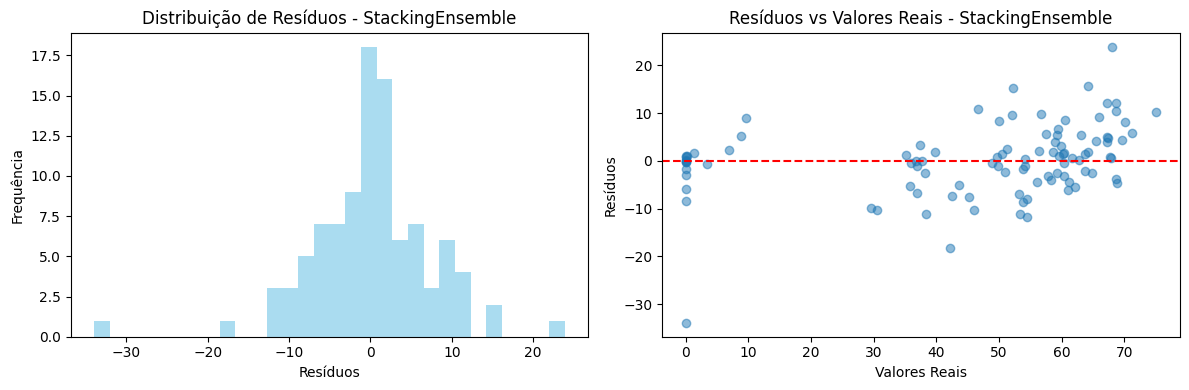

Análise de Resíduos - StackingEnsemble:
  Média: 0.1711 (deve ser próxima de 0)
  Desvio Padrão: 7.4699
  Assimetria: -0.6272 (deve ser próxima de 0)

Análise concluída!
Melhor R² obtido: 0.9297
Gap CV-Test: 4.14%


In [88]:
def main():
    print("="*60)
    print("SISTEMA DE PREDIÇÃO DE SEVERIDADE DO TOMATEIRO")
    print("="*60)

    # Carregar dados
    X, y = load_and_prepare_data()

    # Feature engineering melhorado
    print("\nAplicando feature engineering avançado...")
    X_enhanced = create_improved_features(X)
    print(f"Features originais: {X.shape[1]}")
    print(f"Features após engenharia: {X_enhanced.shape[1]}")

    # Análise melhorada
    pipeline = ImprovedModelPipeline(X_enhanced, y)
    results = pipeline.run_improved_analysis()
    best_model_name, best_model_info = pipeline.print_detailed_summary()

    # Análise de resíduos
    if 'residuals' in best_model_info:
        analyze_residuals(
            best_model_info['residuals'],
            pipeline.y_train,  # ou pipeline.y_test se usar y_pred_test
            best_model_name
        )

    # Visualização de importância das features (modelos com atributo)
    if hasattr(best_model_info['model'], 'feature_importances_') and pipeline.selected_features:
        plt.figure(figsize=(10, 6))
        feature_importance = best_model_info['model'].feature_importances_
        indices = np.argsort(feature_importance)[::-1]
        features = np.array(pipeline.selected_features)[indices]
        importance = feature_importance[indices]

        plt.barh(range(len(features)), importance, align='center')
        plt.yticks(range(len(features)), features)
        plt.xlabel('Importância')
        plt.title('Importância das Features - Melhor Modelo')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()

    print("\nAnálise concluída!")
    print(f"Melhor R² obtido: {best_model_info['test_r2']:.4f}")
    print(f"Gap CV-Test: {best_model_info['cv_test_gap']:.2f}%")

# Executar a análise
if __name__ == "__main__":
    main()
